In [2]:
import os, numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# --- Dataset ---
class MotorSliceDataset(Dataset):
    def __init__(self, samples, sigma=3.0, patch_size=512):
        self.samples = samples
        self.sigma = sigma
        self.ps = patch_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y, x = self.samples[idx]
        img = np.array(Image.open(path).convert("L"), dtype=np.float32)
        lo, hi = np.percentile(img, 0.5), np.percentile(img, 99.5)
        img = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
        h, w = img.shape
        y, x = int(np.clip(y, 0, h-1)), int(np.clip(x, 0, w-1))

        # crop
        if self.ps and self.ps < min(h, w):
            t = max(0, min(y - self.ps//2, h - self.ps))
            l = max(0, min(x - self.ps//2, w - self.ps))
            img = img[t:t+self.ps, l:l+self.ps]
            y, x = y - t, x - l

        # heatmap
        ph, pw = img.shape
        yy, xx = np.meshgrid(np.arange(ph), np.arange(pw), indexing="ij")
        hm = np.exp(-((yy-y)**2 + (xx-x)**2) / (2*self.sigma**2)).astype(np.float32)

        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(hm).unsqueeze(0)

# --- U-Net ---
class Block(nn.Module):
    def __init__(self, inc, outc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1), nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Conv2d(outc, outc, 3, padding=1), nn.BatchNorm2d(outc), nn.ReLU(True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, feat=[32, 64, 128, 256]):
        super().__init__()
        self.encs = nn.ModuleList()
        self.decs = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        inc = 1
        for f in feat:
            self.encs.append(Block(inc, f)); inc = f
        self.bot = Block(feat[-1], feat[-1]*2)
        for f in reversed(feat):
            self.decs.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.decs.append(Block(f*2, f))
        self.head = nn.Conv2d(feat[0], 1, 1)

    def forward(self, x):
        skips = []
        for enc in self.encs:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bot(x)
        skips = skips[::-1]
        for i in range(0, len(self.decs), 2):
            x = self.decs[i](x)
            s = skips[i//2]
            if x.shape != s.shape:
                x = nn.functional.interpolate(x, s.shape[2:])
            x = self.decs[i+1](torch.cat([s, x], 1))
        return torch.sigmoid(self.head(x))

Device: cpu


1. model 
2. train 
3. visualize

In [3]:
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "train_labels.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")

# Train/val ID'lerini oku
with open(os.path.join(BASE_DIR, "train_ids.txt")) as f:
    train_ids = set(l.strip() for l in f)
with open(os.path.join(BASE_DIR, "val_ids.txt")) as f:
    val_ids = set(l.strip() for l in f)

# Sample listesi oluştur
def get_samples(tomo_ids):
    df = pd.read_csv(CSV_PATH)
    df = df[(df["Number of motors"] > 0) & (df["tomo_id"].isin(tomo_ids))]
    samples = []
    for _, r in df.iterrows():
        p = os.path.join(TRAIN_DIR, r["tomo_id"], f"slice_{int(r['Motor axis 0']):04d}.jpg")
        if os.path.exists(p):
            samples.append((p, int(r["Motor axis 1"]), int(r["Motor axis 2"])))
    return samples

train_samples = get_samples(train_ids)
val_samples = get_samples(val_ids)
print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

# Loaderlar
train_loader = DataLoader(MotorSliceDataset(train_samples), batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(MotorSliceDataset(val_samples), batch_size=1, shuffle=False, num_workers=0)

# Model & Training
model = UNet().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

NUM_EPOCHS = 10
train_losses, val_losses = [], []

for ep in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    tloss = 0
    for img, hm in train_loader:
        img, hm = img.to(DEVICE), hm.to(DEVICE)
        pred = model(img)
        loss = loss_fn(pred, hm)
        opt.zero_grad(); loss.backward(); opt.step()
        tloss += loss.item()
    tloss /= max(len(train_loader), 1)

    # Val
    model.eval()
    vloss = 0
    with torch.no_grad():
        for img, hm in val_loader:
            img, hm = img.to(DEVICE), hm.to(DEVICE)
            vloss += loss_fn(model(img), hm).item()
    vloss /= max(len(val_loader), 1)

    train_losses.append(tloss)
    val_losses.append(vloss)
    print(f"Epoch {ep:02d}/{NUM_EPOCHS} | Train: {tloss:.6f} | Val: {vloss:.6f}")

Train: 1, Val: 0
Epoch 01/10 | Train: 0.348574 | Val: 0.000000
Epoch 02/10 | Train: 0.346424 | Val: 0.000000
Epoch 03/10 | Train: 0.344510 | Val: 0.000000
Epoch 04/10 | Train: 0.342648 | Val: 0.000000
Epoch 05/10 | Train: 0.340714 | Val: 0.000000
Epoch 06/10 | Train: 0.338596 | Val: 0.000000
Epoch 07/10 | Train: 0.336173 | Val: 0.000000
Epoch 08/10 | Train: 0.333342 | Val: 0.000000
Epoch 09/10 | Train: 0.330031 | Val: 0.000000
Epoch 10/10 | Train: 0.326268 | Val: 0.000000


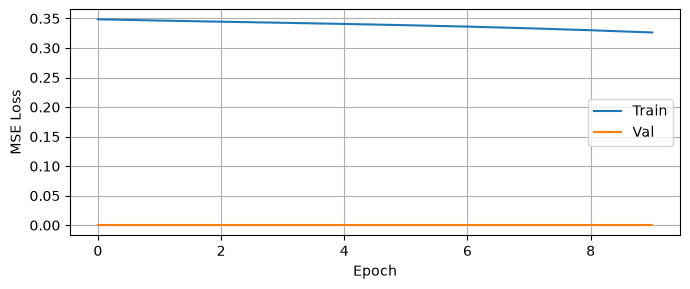

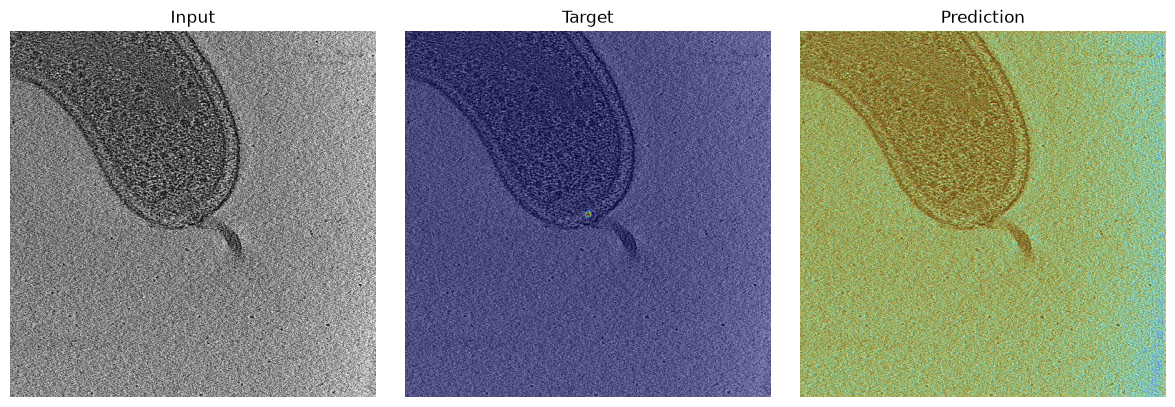

In [4]:
# Loss curve
plt.figure(figsize=(7, 3))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# Predictions
model.eval()
dataset = MotorSliceDataset(val_samples if val_samples else train_samples)
n = min(3, len(dataset))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
if n == 1: axes = axes[np.newaxis, :]

for i in range(n):
    img_t, hm_t = dataset[i]
    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(DEVICE)).cpu().squeeze().numpy()
    img = img_t.squeeze().numpy()
    tgt = hm_t.squeeze().numpy()

    axes[i,0].imshow(img, cmap="gray"); axes[i,0].set_title("Input"); axes[i,0].axis("off")
    axes[i,1].imshow(img, cmap="gray"); axes[i,1].imshow(tgt, cmap="jet", alpha=0.4)
    axes[i,1].set_title("Target"); axes[i,1].axis("off")
    axes[i,2].imshow(img, cmap="gray"); axes[i,2].imshow(pred, cmap="jet", alpha=0.4)
    axes[i,2].set_title("Prediction"); axes[i,2].axis("off")

plt.tight_layout(); plt.show()

step6 = peak detection

Detected 313 motor(s)
  Detection 1: y=128, x=144, score=0.534
  Detection 2: y=16, x=152, score=0.534
  Detection 3: y=152, x=242, score=0.533
  Detection 4: y=126, x=238, score=0.533
  Detection 5: y=16, x=224, score=0.533
  Detection 6: y=182, x=238, score=0.533
  Detection 7: y=482, x=78, score=0.533
  Detection 8: y=412, x=444, score=0.533
  Detection 9: y=214, x=192, score=0.533
  Detection 10: y=58, x=214, score=0.533
  Detection 11: y=178, x=302, score=0.533
  Detection 12: y=152, x=150, score=0.533
  Detection 13: y=76, x=274, score=0.533
  Detection 14: y=180, x=276, score=0.533
  Detection 15: y=74, x=250, score=0.533
  Detection 16: y=214, x=268, score=0.533
  Detection 17: y=84, x=118, score=0.532
  Detection 18: y=132, x=292, score=0.532
  Detection 19: y=222, x=234, score=0.532
  Detection 20: y=50, x=90, score=0.532
  Detection 21: y=138, x=206, score=0.532
  Detection 22: y=36, x=58, score=0.532
  Detection 23: y=36, x=14, score=0.532
  Detection 24: y=112, x=272, scor

C:\Users\beyza.ayguen\AppData\Local\Temp\ipykernel_26560\1765717239.py:83: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  axes[2].scatter(local_x, local_y, s=200, c="green", marker="o",
C:\Users\beyza.ayguen\AppData\Local\Temp\ipykernel_26560\1765717239.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


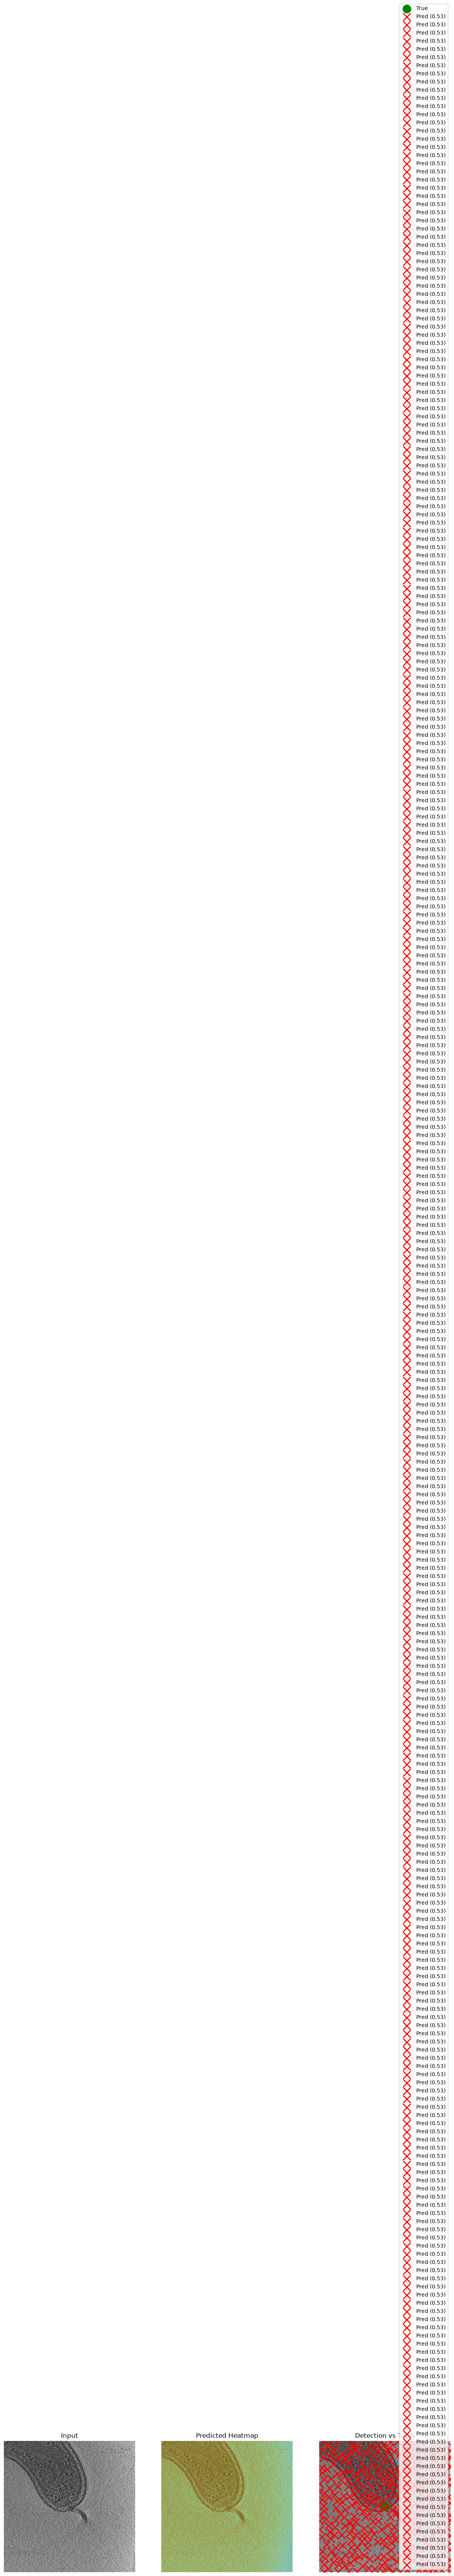

In [6]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])

from scipy.ndimage import maximum_filter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def detect_peaks(heatmap, threshold=0.3, min_distance=20):
    """Heatmap'ten motor koordinatlarını çıkar. Returns: list of (y, x, score)"""
    local_max = maximum_filter(heatmap, size=min_distance)
    peaks_mask = (heatmap == local_max) & (heatmap >= threshold)
    
    ys, xs = np.where(peaks_mask)
    scores = heatmap[ys, xs]
    
    # Score'a göre sırala
    order = np.argsort(-scores)
    ys, xs, scores = ys[order], xs[order], scores[order]
    
    # NMS: yakın olanları ele
    keep = []
    for i in range(len(ys)):
        too_close = False
        for j in keep:
            dist = np.sqrt((ys[i]-ys[j])**2 + (xs[i]-xs[j])**2)
            if dist < min_distance:
                too_close = True
                break
        if not too_close:
            keep.append(i)
    
    return [(ys[i], xs[i], scores[i]) for i in keep]


# --- Prediction yap ---
model.eval()
dataset = MotorSliceDataset(train_samples)
img_t, hm_t = dataset[0]

with torch.no_grad():
    pred_hm = model(img_t.unsqueeze(0).to(DEVICE)).cpu().squeeze().numpy()

# --- Peak detection ---
detections = detect_peaks(pred_hm, threshold=0.2, min_distance=20)
print(f"Detected {len(detections)} motor(s)")
for i, (dy, dx, score) in enumerate(detections):
    print(f"  Detection {i+1}: y={dy}, x={dx}, score={score:.3f}")

# --- Gerçek koordinat ---
_, true_y, true_x = train_samples[0]
print(f"\nTrue motor: y={true_y}, x={true_x}")

# --- Patch offset hesapla ---
img_full = np.array(Image.open(train_samples[0][0]).convert("L"))
h, w = img_full.shape
ps = 512
top = max(0, min(true_y - ps//2, h - ps))
left = max(0, min(true_x - ps//2, w - ps))

if detections:
    dy, dx, _ = detections[0]
    pred_y_global = dy + top
    pred_x_global = dx + left
    distance = np.sqrt((pred_y_global - true_y)**2 + (pred_x_global - true_x)**2)
    print(f"Predicted (global): y={pred_y_global}, x={pred_x_global}")
    print(f"Distance to true: {distance:.1f} pixels")

# --- Görselleştir ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_t.squeeze().numpy(), cmap="gray")
axes[0].set_title("Input"); axes[0].axis("off")

axes[1].imshow(img_t.squeeze().numpy(), cmap="gray")
axes[1].imshow(pred_hm, cmap="jet", alpha=0.4)
axes[1].set_title("Predicted Heatmap"); axes[1].axis("off")

# True vs Predicted
local_y = true_y - top
local_x = true_x - left
axes[2].imshow(img_t.squeeze().numpy(), cmap="gray")
axes[2].scatter(local_x, local_y, s=200, c="green", marker="o",
               linewidths=2, facecolors="none", label="True")
for dy, dx, score in detections:
    axes[2].scatter(dx, dy, s=200, c="red", marker="x",
                   linewidths=2, label=f"Pred ({score:.2f})")
axes[2].set_title("Detection vs Truth")
axes[2].legend(); axes[2].axis("off")

plt.tight_layout(); plt.show()

step7 evaluation

Precision: 0.0032
Recall:    1.0000
F1 Score:  0.0064


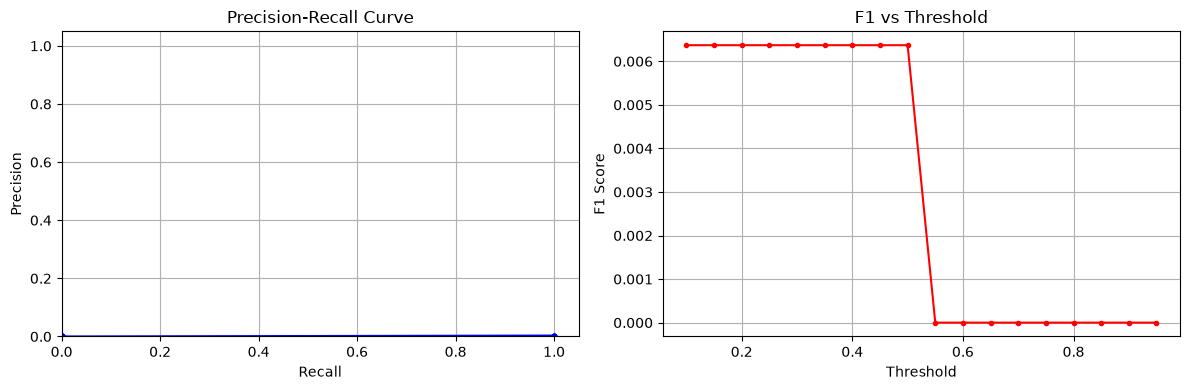


Best threshold: 0.10
Best F1: 0.0064
  Precision: 0.0032
  Recall: 1.0000


In [7]:
def evaluate_detections(all_detections, all_ground_truths, hit_distance=30):
    """
    all_detections: list of list of (y, x, score) per sample
    all_ground_truths: list of (y, x) per sample
    hit_distance: piksel cinsinden eşleşme mesafesi
    
    Returns: precision, recall, f1
    """
    tp = 0  # true positive
    fp = 0  # false positive
    fn = 0  # false negative (kaçırılan motor)
    
    for dets, gt in zip(all_detections, all_ground_truths):
        gt_matched = False
        
        for (dy, dx, score) in dets:
            dist = np.sqrt((dy - gt[0])**2 + (dx - gt[1])**2)
            if dist <= hit_distance and not gt_matched:
                tp += 1
                gt_matched = True
            else:
                fp += 1
        
        if not gt_matched:
            fn += 1
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1


# --- Mevcut 1 sample ile test ---
# Local koordinatlara çevir (patch içi)
img_full = np.array(Image.open(train_samples[0][0]).convert("L"))
h, w = img_full.shape
ps = 512
_, true_y, true_x = train_samples[0]
top = max(0, min(true_y - ps//2, h - ps))
left = max(0, min(true_x - ps//2, w - ps))
local_true_y = true_y - top
local_true_x = true_x - left

# Evaluate
all_dets = [detections]              # Step 6'dan gelen detections
all_gts = [(local_true_y, local_true_x)]  # gerçek koordinat (local)

precision, recall, f1 = evaluate_detections(all_dets, all_gts, hit_distance=30)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Threshold sweep: Precision-Recall curve ---
thresholds = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []

for thr in thresholds:
    dets = detect_peaks(pred_hm, threshold=thr, min_distance=20)
    all_dets = [dets]
    p, r, _ = evaluate_detections(all_dets, all_gts, hit_distance=30)
    precisions.append(p)
    recalls.append(r)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PR Curve
axes[0].plot(recalls, precisions, "b.-")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlim(0, 1.05); axes[0].set_ylim(0, 1.05)
axes[0].grid(True)

# F1 vs Threshold
f1s = [2*p*r/(p+r) if (p+r) > 0 else 0 for p, r in zip(precisions, recalls)]
axes[1].plot(thresholds, f1s, "r.-")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 vs Threshold")
axes[1].grid(True)

plt.tight_layout(); plt.show()

# Optimal threshold
best_idx = np.argmax(f1s)
print(f"\nBest threshold: {thresholds[best_idx]:.2f}")
print(f"Best F1: {f1s[best_idx]:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall: {recalls[best_idx]:.4f}")